In [ ]:
# CELL 1: Upload API Key
from google.colab import files

print("Vui lòng upload file kaggle.json của bạn:")
uploaded = files.upload()

for fn in uploaded.keys():
  print('Đã upload file "{name}" với kích thước {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Vui lòng upload file kaggle.json của bạn:


Saving kaggle.json to kaggle.json
Đã upload file "kaggle.json" với kích thước 63 bytes


In [ ]:
# CELL 2: Cấu hình quyền truy cập
import os

# Tạo thư mục ẩn .kaggle
!mkdir -p ~/.kaggle

# Di chuyển file vừa upload vào thư mục đó
!cp kaggle.json ~/.kaggle/

# Phân quyền bảo mật (bắt buộc)
!chmod 600 ~/.kaggle/kaggle.json

print("Đã cấu hình xong Kaggle API!")

Đã cấu hình xong Kaggle API!


In [ ]:
# CELL 3: Tải dataset Deepfake 140k từ Kaggle
import os

# Xóa folder cũ nếu có để tránh lỗi
!rm -rf deepfake_140k_dataset
!rm -rf real_vs_fake

print("Đang tải dataset Deepfake 140k...")
# Dataset phổ biến của xhlulu trên Kaggle
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces

print("Đang giải nén (Quá trình này mất khoảng 1-2 phút)...")
# Giải nén
!unzip -q 140k-real-and-fake-faces.zip -d deepfake_140k_dataset

print("Hoàn tất! Kiểm tra cấu trúc thư mục:")
# Kiểm tra đường dẫn thực tế sau khi giải nén
base_dir = 'deepfake_140k_dataset/real_vs_fake/real-vs-fake'
if os.path.exists(base_dir):
    print(os.listdir(base_dir))
    DATASET_PATH = base_dir # Lưu đường dẫn gốc
else:
    # Fallback nếu cấu trúc khác
    print("Cấu trúc thư mục lạ, vui lòng kiểm tra tab Files bên trái")

Đang tải dataset Deepfake 140k...
Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
 99% 3.73G/3.75G [01:11<00:00, 69.2MB/s]
100% 3.75G/3.75G [01:11<00:00, 55.9MB/s]
Đang giải nén (Quá trình này mất khoảng 1-2 phút)...
Hoàn tất! Kiểm tra cấu trúc thư mục:
['test', 'train', 'valid']


In [ ]:
import os
import shutil
import random
from tqdm import tqdm

# Cấu hình đường dẫn
SOURCE_DIR = 'deepfake_140k_dataset/real_vs_fake/real-vs-fake' # Folder gốc 140k
TARGET_DIR = 'mini_dataset' # Folder mới

# Số lượng ảnh MONG MUỐN lấy cho mỗi lớp ở tập TRAIN
# (Valid và Test sẽ lấy theo tỷ lệ tương ứng ít hơn)
# Giảm xuống 10k mỗi lớp (Tổng train = 5k) -> Train siêu nhanh
LIMIT_PER_CLASS_TRAIN = 2500
LIMIT_PER_CLASS_VAL   = 500
LIMIT_PER_CLASS_TEST  = 500

def create_subset(subset_name, limit):
    print(f"\nDang xu ly tap: {subset_name}...")
    for label in ['real', 'fake']:
        src_folder = os.path.join(SOURCE_DIR, subset_name, label)
        dst_folder = os.path.join(TARGET_DIR, subset_name, label)

        # Tạo folder đích
        os.makedirs(dst_folder, exist_ok=True)

        # Lấy danh sách file
        if not os.path.exists(src_folder):
            print(f"Khong tim thay: {src_folder}")
            continue

        files = os.listdir(src_folder)
        random.shuffle(files) # Trộn ngẫu nhiên để dữ liệu khách quan

        # Cắt bớt danh sách
        selected_files = files[:limit]

        print(f"  - {label}: Copying {len(selected_files)} files...")

        # Copy file
        for f in tqdm(selected_files):
            shutil.copy(os.path.join(src_folder, f), os.path.join(dst_folder, f))

# Xóa nếu đã tồn tại để làm mới
if os.path.exists(TARGET_DIR):
    shutil.rmtree(TARGET_DIR)

# Thực hiện copy
create_subset('train', LIMIT_PER_CLASS_TRAIN)
create_subset('valid', LIMIT_PER_CLASS_VAL)
create_subset('test', LIMIT_PER_CLASS_TEST)

print("\nHOAN TAT! Da tao dataset thu gon tai folder 'mini_dataset'")


Dang xu ly tap: train...
  - real: Copying 2500 files...


100%|██████████| 2500/2500 [00:00<00:00, 8571.36it/s]


  - fake: Copying 2500 files...


100%|██████████| 2500/2500 [00:03<00:00, 703.93it/s]



Dang xu ly tap: valid...
  - real: Copying 500 files...


...


Dang xu ly tap: test...
  - real: Copying 500 files...


100%|██████████| 500/500 [00:00<00:00, 530.09it/s]


  - fake: Copying 500 files...


100%|██████████| 500/500 [00:00<00:00, 526.37it/s]


HOAN TAT! Da tao dataset thu gon tai folder 'mini_dataset'


In [ ]:
import os
import shutil
import random
from google.colab import files

# 1. CẤU HÌNH
SOURCE_BASE = 'mini_dataset/test' # Lấy từ tập Test cho khách quan
OUTPUT_FOLDER = 'demo_batch_images'
NUM_IMAGES_PER_CLASS = 25 # 25 Real + 25 Fake = 50 ảnh

# 2. TẠO FOLDER ĐÍCH
if os.path.exists(OUTPUT_FOLDER):
    shutil.rmtree(OUTPUT_FOLDER)
os.makedirs(OUTPUT_FOLDER)

print(f"📂 Đang tạo bộ dữ liệu demo tại: {OUTPUT_FOLDER}")

# 3. HÀM COPY VÀ ĐỔI TÊN
def copy_samples(label_type):
    # Đường dẫn nguồn (Ví dụ: mini_dataset/test/Real)
    # Lưu ý: Kiểm tra xem cấu trúc folder của bạn là 'Real' hay '0'
    # Dựa vào các bước trước, mình giả định là 'Real' và 'Fake'
    source_path = os.path.join(SOURCE_BASE, label_type)

    # Lấy danh sách ảnh
    all_files = os.listdir(source_path)
    # Chọn ngẫu nhiên
    selected_files = random.sample(all_files, NUM_IMAGES_PER_CLASS)

    count = 0
    for file_name in selected_files:
        src = os.path.join(source_path, file_name)

        # Đổi tên file để dễ đối chiếu (VD: real_01.jpg, fake_05.jpg)
        # Giữ nguyên đuôi file (jpg/png)
        ext = file_name.split('.')[-1]
        new_name = f"{label_type.lower()}_{count:03d}.{ext}"
        dst = os.path.join(OUTPUT_FOLDER, new_name)

        shutil.copy(src, dst)
        count += 1

    print(f"✅ Đã chép {count} ảnh {label_type}")

# 4. THỰC THI
try:
    copy_samples('real')
    copy_samples('fake')

    print("-" * 30)
    print(f"🎉 Hoàn tất! Tổng cộng {len(os.listdir(OUTPUT_FOLDER))} ảnh trong folder '{OUTPUT_FOLDER}'")

    # 5. NÉN THÀNH ZIP ĐỂ TẢI VỀ
    print("📦 Đang nén file zip...")
    shutil.make_archive('demo_images', 'zip', OUTPUT_FOLDER)

    # 6. TỰ ĐỘNG TẢI XUỐNG
    print("⬇️ Đang tải xuống máy tính...")
    files.download('demo_images.zip')

except Exception as e:
    print(f"❌ Có lỗi xảy ra: {e}")
    print("Gợi ý: Hãy kiểm tra lại đường dẫn SOURCE_BASE xem tên folder là 'Real'/'Fake' hay '0'/'1'")

📂 Đang tạo bộ dữ liệu demo tại: demo_batch_images
✅ Đã chép 25 ảnh real
✅ Đã chép 25 ảnh fake
------------------------------
🎉 Hoàn tất! Tổng cộng 50 ảnh trong folder 'demo_batch_images'
📦 Đang nén file zip...
⬇️ Đang tải xuống máy tính...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Đường dẫn hợp lệ. Bắt đầu xử lý...

=== BẢNG THỐNG KÊ CHI TIẾT ===
Tập        | Real       | Fake       | Tổng      
----------------------------------------------
Train      | 2500       | 2500       | 5000      
Valid      | 500        | 500        | 1000      
Test       | 500        | 500        | 1000      
----------------------------------------------
TOÀN BỘ    | 3500       | 3500       | 7000      

Đã lưu biểu đồ: deepfake_distribution.png


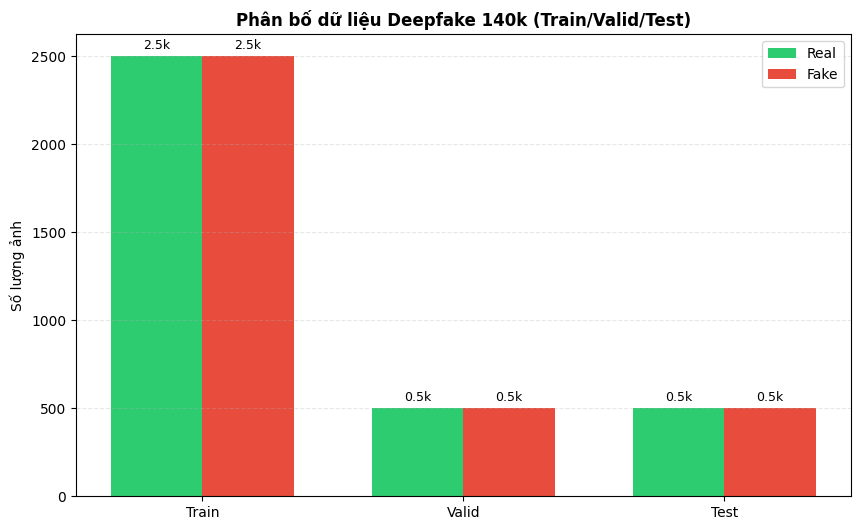

Đã lưu ảnh mẫu: deepfake_samples.png


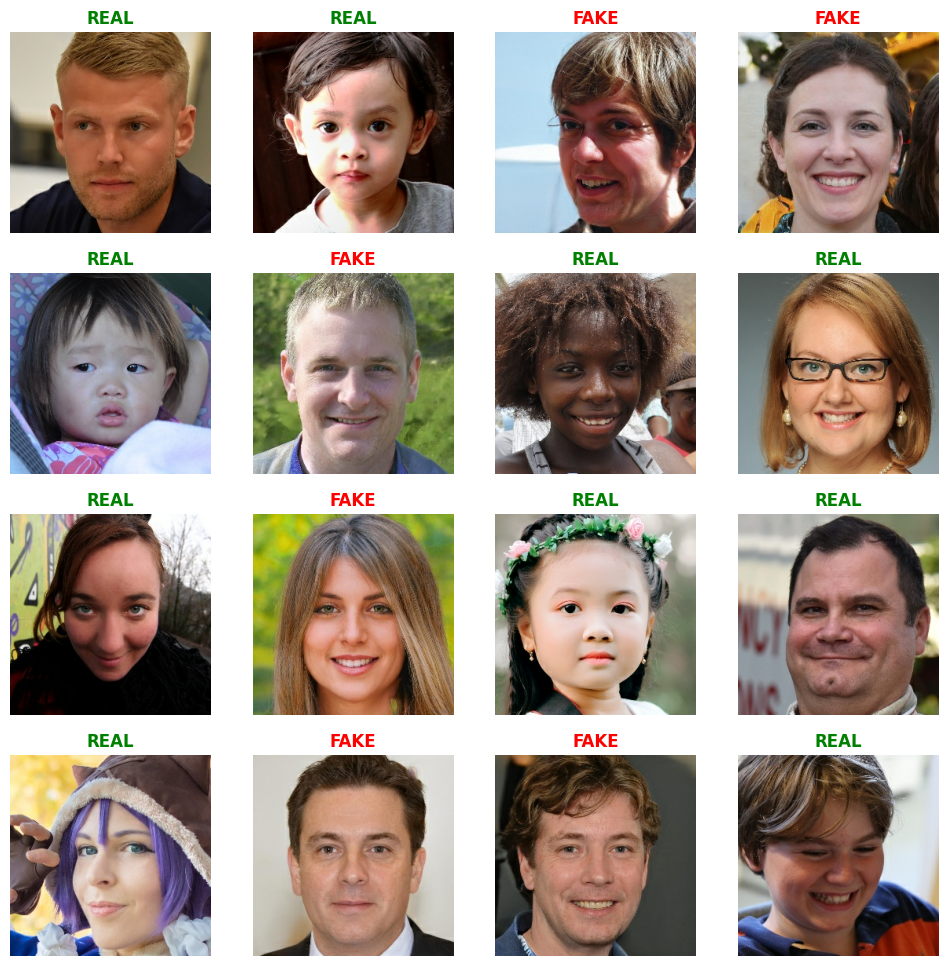

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN (Dựa trên ảnh của bạn)
# ==========================================
base_dir = 'mini_dataset'

train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'valid')
test_dir  = os.path.join(base_dir, 'test')

# Kiểm tra đường dẫn có tồn tại không
if not os.path.exists(base_dir):
    print(f"Lỗi: Không tìm thấy đường dẫn {base_dir}")
    print("Vui lòng kiểm tra lại quá trình giải nén ở bước trước.")
else:
    print("Đường dẫn hợp lệ. Bắt đầu xử lý...")

    # ==========================================
    # 2. THỐNG KÊ SỐ LƯỢNG ẢNH
    # ==========================================
    def count_images(dir_path):
        if not os.path.exists(dir_path): return 0, 0
        real = len(os.listdir(os.path.join(dir_path, 'real')))
        fake = len(os.listdir(os.path.join(dir_path, 'fake')))
        return real, fake

    tr_real, tr_fake = count_images(train_dir)
    val_real, val_fake = count_images(val_dir)
    ts_real, ts_fake = count_images(test_dir)

    total_real = tr_real + val_real + ts_real
    total_fake = tr_fake + val_fake + ts_fake
    total_imgs = total_real + total_fake

    print("\n=== BẢNG THỐNG KÊ CHI TIẾT ===")
    print(f"{'Tập':<10} | {'Real':<10} | {'Fake':<10} | {'Tổng':<10}")
    print("-" * 46)
    print(f"{'Train':<10} | {tr_real:<10} | {tr_fake:<10} | {tr_real+tr_fake:<10}")
    print(f"{'Valid':<10} | {val_real:<10} | {val_fake:<10} | {val_real+val_fake:<10}")
    print(f"{'Test':<10} | {ts_real:<10} | {ts_fake:<10} | {ts_real+ts_fake:<10}")
    print("-" * 46)
    print(f"{'TOÀN BỘ':<10} | {total_real:<10} | {total_fake:<10} | {total_imgs:<10}")

    # ==========================================
    # 3. VẼ BIỂU ĐỒ PHÂN BỐ (Lưu ảnh 1)
    # ==========================================
    labels = ['Train', 'Valid', 'Test']
    real_counts = [tr_real, val_real, ts_real]
    fake_counts = [tr_fake, val_fake, ts_fake]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(10, 6))
    rects1 = plt.bar(x - width/2, real_counts, width, label='Real', color='#2ecc71')
    rects2 = plt.bar(x + width/2, fake_counts, width, label='Fake', color='#e74c3c')

    plt.ylabel('Số lượng ảnh')
    plt.title('Phân bố dữ liệu Deepfake 140k (Train/Valid/Test)', fontweight='bold')
    plt.xticks(x, labels)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Thêm số liệu lên cột
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            plt.annotate(f'{height/1000:.1f}k',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    autolabel(rects1)
    autolabel(rects2)

    plt.savefig('deepfake_distribution.png', dpi=300, bbox_inches='tight')
    print("\nĐã lưu biểu đồ: deepfake_distribution.png")
    plt.show()

    # ==========================================
    # 4. VISUALIZE MẪU ẢNH (Lưu ảnh 2)
    # ==========================================
    # Load batch từ tập Train để hiển thị
    viz_ds = image_dataset_from_directory(
        train_dir,
        image_size=(256, 256),
        batch_size=32,
        shuffle=True,
        label_mode='int',
        seed=42,
        verbose=0
    )

    class_names = viz_ds.class_names # thường là ['fake', 'real']

    plt.figure(figsize=(12, 12))
    for images, labels in viz_ds.take(1):
        for i in range(16):
            ax = plt.subplot(4, 4, i + 1)
            img = images[i].numpy().astype("uint8")
            plt.imshow(img)

            label_idx = labels[i]
            label_name = class_names[label_idx]

            # Real = Xanh, Fake = Đỏ
            color = 'green' if label_name == 'real' else 'red'

            plt.title(label_name.upper(), color=color, fontweight='bold')
            plt.axis("off")

    plt.savefig('deepfake_samples.png', dpi=300, bbox_inches='tight')
    print("Đã lưu ảnh mẫu: deepfake_samples.png")
    plt.show()

Found 5000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Bắt đầu huấn luyện Baseline...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 44s 174ms/step - accuracy: 0.5667 - loss: 0.7055 - val_accuracy: 0.7080 - val_loss: 0.5687
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.7009 - loss: 0.5689 - val_accuracy: 0.7340 - val_loss: 0.5391
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7347 - loss: 0.5310 - val_accuracy: 0.7340 - val_loss: 0.5221
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7475 - loss: 0.5084 - val_accuracy: 0.7410 - val_loss: 0.5144
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7679 - loss: 0.4837 - val_accuracy: 0.7500 - val_loss: 0.5055
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7662 - loss: 0.4797 - val_accuracy: 0.7510 - val_loss: 0.4990
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.7764 - loss: 0.4735 - val_accuracy: 0.7510 - val_loss: 0.4933
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy:

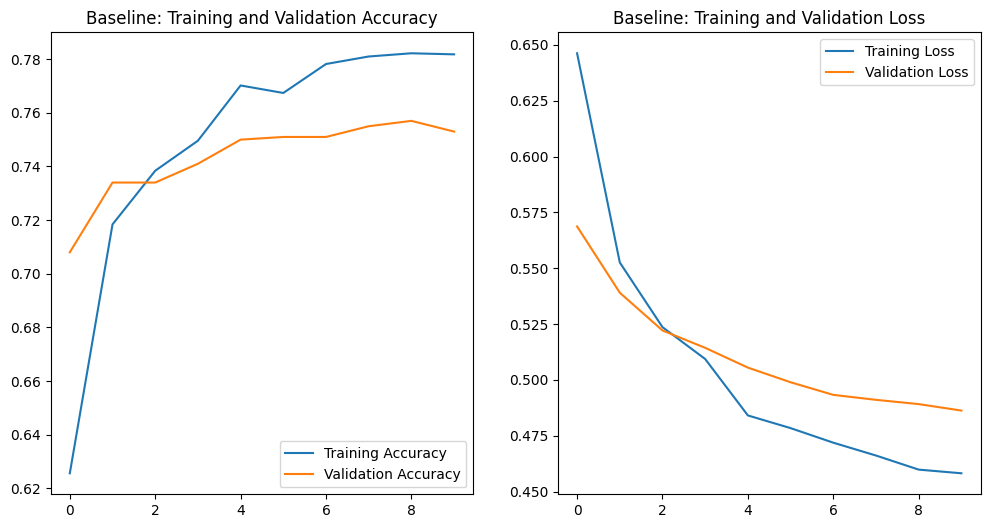

Đã lưu model: baseline_model.h5


In [ ]:
# CELL 7: Xây dựng và Huấn luyện Mô hình Baseline (MobileNetV2)
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import os

# 1. Cấu hình
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10  # Baseline chỉ cần chạy ít để lấy mốc so sánh
LEARNING_RATE = 0.001

# Load lại dữ liệu (Đảm bảo đúng đường dẫn như các bước trước)
# Lưu ý: Cần load lại với size 224x224
base_dir = 'mini_dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')

# Hàm load dataset chuẩn cho MobileNet
def load_dataset(path):
    return tf.keras.preprocessing.image_dataset_from_directory(
        path,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='binary',
        shuffle=True
    )

train_ds = load_dataset(train_dir)
val_ds = load_dataset(val_dir)
test_ds = load_dataset(test_dir)

# Tối ưu hóa hiệu năng (Prefetching)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# -----------------------------------------------------------
# 2. XÂY DỰNG MÔ HÌNH BASELINE
# -----------------------------------------------------------
# Tải MobileNetV2, bỏ lớp Top (lớp phân loại 1000 lớp của ImageNet)
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')

# ĐÓNG BĂNG (FREEZE) Base Model
# Đây là đặc điểm của Baseline: Chỉ dùng MobileNet làm bộ trích xuất đặc trưng
base_model.trainable = False

# Xây dựng kiến trúc tổng thể
inputs = tf.keras.Input(shape=(224, 224, 3))

# Tiền xử lý: MobileNetV2 yêu cầu input [-1, 1]
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

# Đi qua Augmentation (nếu đã tích hợp vào model, hoặc dùng ở bước dataset)
# x = data_augmentation(x) # Tạm tắt để demo baseline thuần túy

x = base_model(x, training=False) # training=False để khóa BatchNormalization
x = layers.GlobalAveragePooling2D()(x) # Biến đổi thành vector đặc trưng
x = layers.Dropout(0.2)(x) # Chống overfitting
outputs = layers.Dense(1, activation='sigmoid')(x) # Output nhị phân

model_baseline = tf.keras.Model(inputs, outputs)

# Compile mô hình
model_baseline.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

model_baseline.summary()

# -----------------------------------------------------------
# 3. HUẤN LUYỆN
# -----------------------------------------------------------
print("Bắt đầu huấn luyện Baseline...")
history_baseline = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# -----------------------------------------------------------
# 4. VẼ BIỂU ĐỒ VÀ LƯU KẾT QUẢ
# -----------------------------------------------------------
acc = history_baseline.history['accuracy']
val_acc = history_baseline.history['val_accuracy']
loss = history_baseline.history['loss']
val_loss = history_baseline.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 6))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Baseline: Training and Validation Accuracy')

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Baseline: Training and Validation Loss')

plt.savefig('baseline_training_history.png', dpi=300)
print("Đã lưu biểu đồ: baseline_training_history.png")
plt.show()

# Lưu model để dùng sau này
model_baseline.save('baseline_model.h5')
print("Đã lưu model: baseline_model.h5")

Số lượng lớp trong Base Model: 154
Bắt đầu train từ lớp: 100


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,862,721 (7.11 MB)

 Non-trainable params: 396,544 (1.51 MB)

Bắt đầu huấn luyện Version 2 (Fine-tuning)...
Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 46s 158ms/step - accuracy: 0.5603 - loss: 0.7112 - val_accuracy: 0.5010 - val_loss: 1.1516
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.7420 - loss: 0.5193 - val_accuracy: 0.5040 - val_loss: 1.2767
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8083 - loss: 0.4274 - val_accuracy: 0.5090 - val_loss: 1.2568
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.8506 - loss: 0.3630 - val_accuracy: 0.5190 - val_loss: 1.2067
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.8854 - loss: 0.3025 - val_accuracy: 0.5390 - val_loss: 1.1529
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.9092 - loss: 0.2551 - val_accuracy: 0.5690 - val_loss: 1.0840
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9329 - loss: 0.2071 - val_accuracy: 0.6000 - val_loss: 0.9984
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/

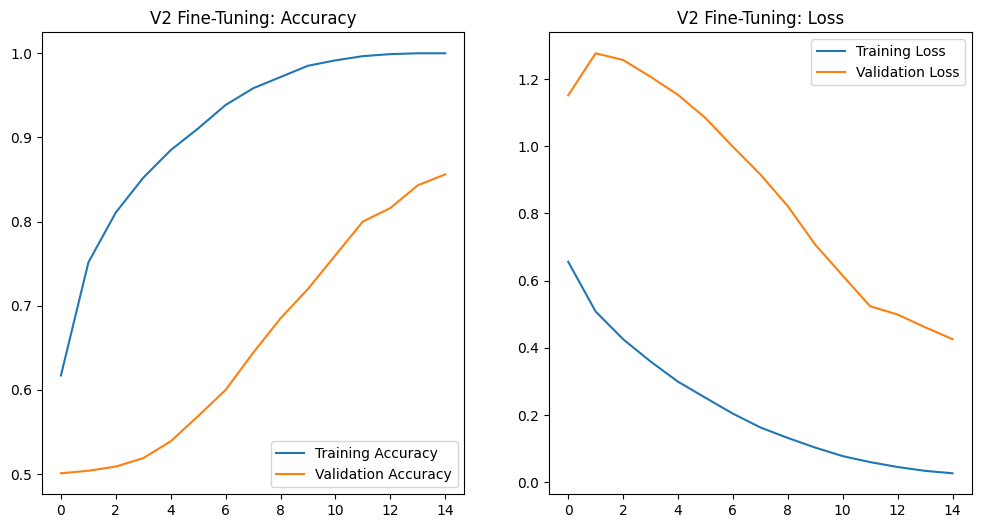

In [ ]:
# CELL 8: VERSION 2 - Fine-Tuning MobileNetV2
# Lưu ý: Chạy tiếp nối sau khi đã load dataset ở các bước trước

# -----------------------------------------------------------
# CẤU HÌNH V2
# -----------------------------------------------------------
# Giảm Learning Rate đi 10-100 lần so với Baseline
FINE_TUNE_LR = 1e-5
EPOCHS_V2 = 15 # Tăng số epoch lên vì học chậm cần nhiều thời gian hơn

# -----------------------------------------------------------
# XÂY DỰNG MÔ HÌNH (Sửa đổi từ Baseline)
# -----------------------------------------------------------
base_model_v2 = MobileNetV2(input_shape=(224, 224, 3),
                            include_top=False,
                            weights='imagenet')

# BƯỚC QUAN TRỌNG: Mở băng một phần (Partial Unfreezing)
base_model_v2.trainable = True # Đầu tiên cho phép train toàn bộ

# Sau đó đóng băng lại các lớp đầu (để giữ lại đặc trưng cơ bản như cạnh, góc)
# MobileNetV2 có khoảng 155 lớp. Ta sẽ đóng băng 100 lớp đầu, train 55 lớp cuối.
fine_tune_at = 100

for layer in base_model_v2.layers[:fine_tune_at]:
    layer.trainable = False

# Kiểm tra xem có bao nhiêu lớp được train
print(f"Số lượng lớp trong Base Model: {len(base_model_v2.layers)}")
print(f"Bắt đầu train từ lớp: {fine_tune_at}")

# Xây dựng kiến trúc (như cũ)
inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model_v2(x, training=False) # Quan trọng: Vẫn giữ training=False cho BatchNormalization layer
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_v2 = tf.keras.Model(inputs, outputs)

# Compile với Learning Rate nhỏ
model_v2.compile(optimizer=optimizers.Adam(learning_rate=FINE_TUNE_LR),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

model_v2.summary()

# -----------------------------------------------------------
# HUẤN LUYỆN
# -----------------------------------------------------------
print("Bắt đầu huấn luyện Version 2 (Fine-tuning)...")
history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_V2
)

# -----------------------------------------------------------
# VẼ BIỂU ĐỒ SO SÁNH
# -----------------------------------------------------------
acc = history_v2.history['accuracy']
val_acc = history_v2.history['val_accuracy']
loss = history_v2.history['loss']
val_loss = history_v2.history['val_loss']
epochs_range = range(EPOCHS_V2)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('V2 Fine-Tuning: Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('V2 Fine-Tuning: Loss')
plt.show()

model_v2.save('model_v2_finetune.h5')

Bắt đầu huấn luyện Version 3 (Augmentation + Dropout 0.5)...
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5421 - loss: 0.7991

157/157 ━━━━━━━━━━━━━━━━━━━━ 34s 109ms/step - accuracy: 0.5422 - loss: 0.7988 - val_accuracy: 0.5490 - val_loss: 0.7329
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.6363 - loss: 0.6607 - val_accuracy: 0.5220 - val_loss: 0.9306
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 0.6807 - loss: 0.6031 - val_accuracy: 0.5220 - val_loss: 0.9878
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.7003 - loss: 0.5647 - val_accuracy: 0.5250 - val_loss: 1.0756
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.7256 - loss: 0.5386 - val_accuracy: 0.5480 - val_loss: 0.9361
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.7440 - loss: 0.5217 - val_accuracy: 0.5690 - val_loss: 0.8948
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


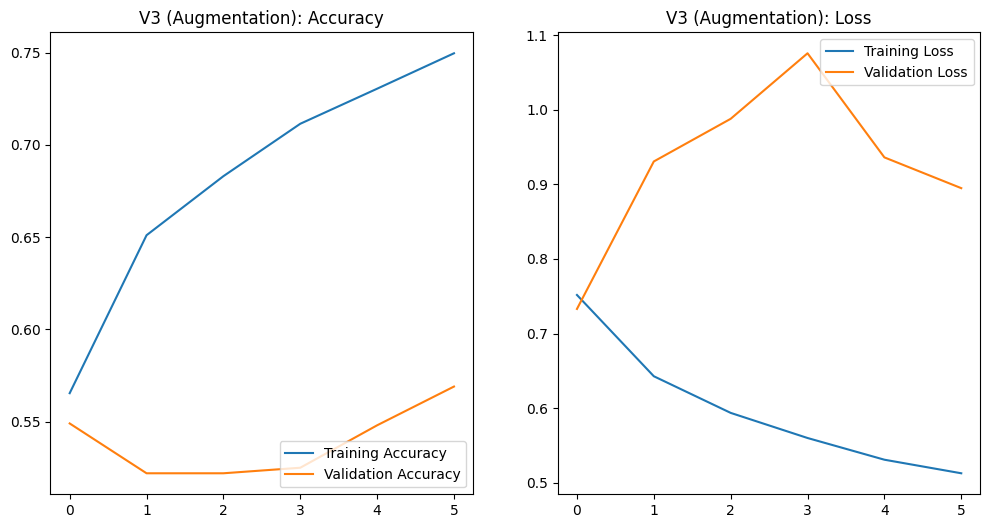

In [ ]:
# CELL 9: VERSION 3 - Data Augmentation & Regularization
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# -----------------------------------------------------------
# 1. ĐỊNH NGHĨA DATA AUGMENTATION
# -----------------------------------------------------------
# Ta tạo một layer riêng cho việc này.
# Lưu ý: Các biến đổi này chỉ hoạt động khi training=True.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"), # Lật ảnh ngang ngẫu nhiên
    layers.RandomRotation(0.1),      # Xoay ngẫu nhiên khoảng 10% (36 độ)
    layers.RandomZoom(0.1),          # Phóng to/nhỏ ngẫu nhiên 10%
    layers.RandomContrast(0.1),      # Thay đổi độ tương phản
])

# -----------------------------------------------------------
# 2. XÂY DỰNG MÔ HÌNH V3
# -----------------------------------------------------------
# Vẫn dùng MobileNetV2 và Fine-tuning như V2
base_model_v3 = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model_v3.trainable = True
# Đóng băng 100 lớp đầu, train các lớp sau (giống V2)
for layer in base_model_v3.layers[:100]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

# --- THAY ĐỔI LỚN Ở ĐÂY ---
# Đưa ảnh qua Augmentation trước khi vào model
x = data_augmentation(inputs)
# --------------------------

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model_v3(x, training=False)
x = layers.GlobalAveragePooling2D()(x)

# --- THAY ĐỔI LỚN Ở ĐÂY ---
x = layers.Dropout(0.5)(x) # Tăng Dropout từ 0.2 lên 0.5 để phạt nặng hơn
# --------------------------

outputs = layers.Dense(1, activation='sigmoid')(x)

model_v3 = tf.keras.Model(inputs, outputs)

model_v3.compile(optimizer=optimizers.Adam(learning_rate=1e-5), # Vẫn giữ LR thấp
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# -----------------------------------------------------------
# 3. THIẾT LẬP CALLBACKS (Dừng sớm & Lưu model tốt nhất)
# -----------------------------------------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True),
    ModelCheckpoint('model_v3_best.h5', monitor='val_loss', save_best_only=True)
]

# -----------------------------------------------------------
# 4. HUẤN LUYỆN
# -----------------------------------------------------------
print("Bắt đầu huấn luyện Version 3 (Augmentation + Dropout 0.5)...")
history_v3 = model_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, # Tăng epoch lên vì có Augmentation mô hình sẽ học chậm hơn
    callbacks=callbacks
)

# -----------------------------------------------------------
# 5. VẼ BIỂU ĐỒ
# -----------------------------------------------------------
import matplotlib.pyplot as plt

acc = history_v3.history['accuracy']
val_acc = history_v3.history['val_accuracy']
loss = history_v3.history['loss']
val_loss = history_v3.history['val_loss']
real_epochs = range(len(acc)) # Lấy số epoch thực tế (do early stopping)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(real_epochs, acc, label='Training Accuracy')
plt.plot(real_epochs, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('V3 (Augmentation): Accuracy')

plt.subplot(1, 2, 2)
plt.plot(real_epochs, loss, label='Training Loss')
plt.plot(real_epochs, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('V3 (Augmentation): Loss')
plt.show()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_3 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_3 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,201 (9.87 MB)

 Trainable params: 328,705 (1.25 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

...

157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.7732 - loss: 0.4741 - val_accuracy: 0.7630 - val_loss: 0.5060
Epoch 11/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7754 - loss: 0.4655

157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.7754 - loss: 0.4656 - val_accuracy: 0.7580 - val_loss: 0.4994
Epoch 12/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.7670 - loss: 0.4688 - val_accuracy: 0.7520 - val_loss: 0.5302
Epoch 13/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.7722 - loss: 0.4728 - val_accuracy: 0.7550 - val_loss: 0.5005
Epoch 14/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7760 - loss: 0.4602

157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.7761 - loss: 0.4602 - val_accuracy: 0.7610 - val_loss: 0.4934
Epoch 15/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.7844 - loss: 0.4531 - val_accuracy: 0.7510 - val_loss: 0.5418
Epoch 16/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7823 - loss: 0.4511

157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.7825 - loss: 0.4511 - val_accuracy: 0.7690 - val_loss: 0.4933
Epoch 17/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.7776 - loss: 0.4512 - val_accuracy: 0.7520 - val_loss: 0.5041
Epoch 18/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7942 - loss: 0.4456

157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.7942 - loss: 0.4457 - val_accuracy: 0.7650 - val_loss: 0.4904
Epoch 19/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.7810 - loss: 0.4596 - val_accuracy: 0.7660 - val_loss: 0.5032
Epoch 20/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.7911 - loss: 0.4433 - val_accuracy: 0.7650 - val_loss: 0.4970
Restoring model weights from the end of the best epoch: 18.


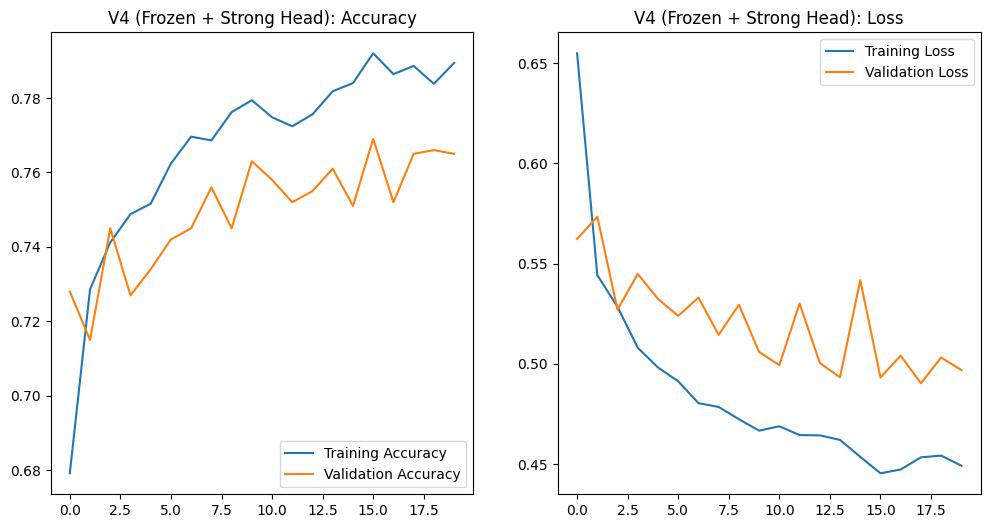

In [ ]:
# CELL 10: VERSION 4 - Frozen Base + Stronger Head
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# -----------------------------------------------------------
# 1. CẤU HÌNH & AUGMENTATION
# -----------------------------------------------------------
# Giữ nguyên Augmentation như V3
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# -----------------------------------------------------------
# 2. XÂY DỰNG MÔ HÌNH V4 (Kiến trúc mới)
# -----------------------------------------------------------
base_model_v4 = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# QUAN TRỌNG: Đóng băng toàn bộ Base Model
# Ta thà dùng đặc trưng có sẵn của ImageNet còn hơn để nó bị phá hỏng
base_model_v4.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

# Augmentation -> Preprocess -> Base Model
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model_v4(x, training=False) # training=False cực quan trọng khi freeze

x = layers.GlobalAveragePooling2D()(x)

# --- NÂNG CẤP LỚP PHÂN LOẠI (HEAD) ---
# Thêm một lớp Dense để tăng khả năng học các đặc trưng phức tạp
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x) # Giúp ổn định quá trình train
x = layers.Dropout(0.3)(x)         # Dropout vừa phải (0.3)

outputs = layers.Dense(1, activation='sigmoid')(x)

model_v4 = tf.keras.Model(inputs, outputs)

# Compile với LR chuẩn 1e-3 (vì chỉ train các lớp mới thêm vào)
model_v4.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

model_v4.summary()

# -----------------------------------------------------------
# 3. HUẤN LUYỆN
# -----------------------------------------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True),
    ModelCheckpoint('model_v4_best.h5', monitor='val_loss', save_best_only=True)
]

print("Bắt đầu huấn luyện Version 4 (Frozen Base + Strong Head)...")
history_v4 = model_v4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

# -----------------------------------------------------------
# 4. VẼ BIỂU ĐỒ
# -----------------------------------------------------------
import matplotlib.pyplot as plt

acc = history_v4.history['accuracy']
val_acc = history_v4.history['val_accuracy']
loss = history_v4.history['loss']
val_loss = history_v4.history['val_loss']
real_epochs = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(real_epochs, acc, label='Training Accuracy')
plt.plot(real_epochs, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('V4 (Frozen + Strong Head): Accuracy')

plt.subplot(1, 2, 2)
plt.plot(real_epochs, loss, label='Training Loss')
plt.plot(real_epochs, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('V4 (Frozen + Strong Head): Loss')
plt.show()

Đang thiết lập Version 5 dựa trên Model V4...
Số lớp trong MobileNet: 154
Số lớp được train (Unfrozen): 54


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_3 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_3 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,201 (9.87 MB)

 Trainable params: 2,190,145 (8.35 MB)

...

157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - accuracy: 0.8773 - loss: 0.2916 - val_accuracy: 0.8540 - val_loss: 0.3471
Epoch 16/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8891 - loss: 0.2680

157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - accuracy: 0.8891 - loss: 0.2679 - val_accuracy: 0.8520 - val_loss: 0.3454
Epoch 17/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8967 - loss: 0.2552

157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - accuracy: 0.8967 - loss: 0.2551 - val_accuracy: 0.8510 - val_loss: 0.3386
Epoch 18/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9025 - loss: 0.2458

157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 105ms/step - accuracy: 0.9026 - loss: 0.2457 - val_accuracy: 0.8570 - val_loss: 0.3343
Epoch 19/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - accuracy: 0.9010 - loss: 0.2382 - val_accuracy: 0.8550 - val_loss: 0.3429
Epoch 20/20
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9076 - loss: 0.2311

157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.9077 - loss: 0.2310 - val_accuracy: 0.8650 - val_loss: 0.3142
Restoring model weights from the end of the best epoch: 20.


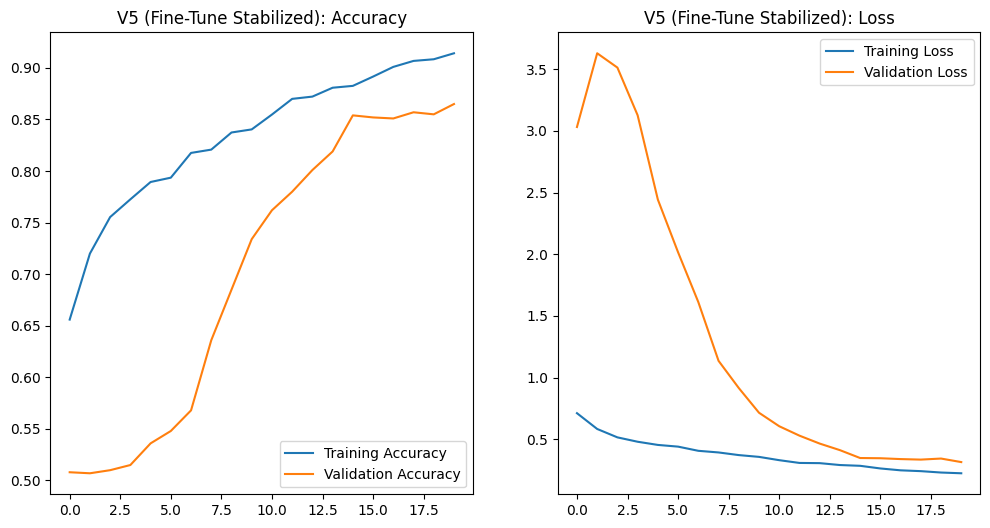

In [ ]:
# CELL 11: VERSION 5 - Fine-Tuning the Stabilized Model
# Yêu cầu: Phải chạy CELL 10 (Version 4) thành công trước khi chạy Cell này.

print("Đang thiết lập Version 5 dựa trên Model V4...")

# 1. MỞ KHÓA BASE MODEL
# Truy cập vào layer MobileNetV2 bên trong model_v4
# Trong kiến trúc V4: Input -> Augmentation -> Preprocess -> MobileNetV2 -> Pooling...
# Ta cần tìm layer có tên là 'mobilenetv2_1.0_224' (hoặc dựa vào index)

base_model_layer = base_model_v4 # Chúng ta đã khai báo biến này ở Cell 10
base_model_layer.trainable = True # Mở khóa toàn bộ trước

# 2. ĐÓNG BĂNG LẠI CÁC LỚP ĐẦU
# Giống như V2, ta giữ lại các đặc trưng cơ bản (cạnh, góc)
# và chỉ cho phép train các lớp trích xuất đặc trưng cao cấp (texture, noise)
fine_tune_at = 100

for layer in base_model_layer.layers[:fine_tune_at]:
    layer.trainable = False

# Kiểm tra lại
print(f"Số lớp trong MobileNet: {len(base_model_layer.layers)}")
print(f"Số lớp được train (Unfrozen): {len(base_model_layer.layers) - fine_tune_at}")

# 3. COMPILE LẠI MÔ HÌNH
# Quan trọng: Vì model_v4 đã được build, ta chỉ cần compile lại với LR nhỏ
# Model bây giờ bao gồm cả trọng số đã học ở V4
model_v4.compile(optimizer=optimizers.Adam(learning_rate=1e-5), # Học cực chậm
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# Đổi tên biến cho rõ ràng
model_v5 = model_v4
model_v5.summary()

# 4. HUẤN LUYỆN TIẾP (Fine-tuning)
# Ta train tiếp tục, nhưng model sẽ bắt đầu từ mức accuracy ~76% của V4 chứ không phải từ 50%
print("Bắt đầu Fine-tuning V5...")

callbacks_v5 = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True),
    ModelCheckpoint('model_v5_best.h5', monitor='val_loss', save_best_only=True)
]

history_v5 = model_v5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, # Train thêm 20 epoch nữa
    initial_epoch=0, # Reset lại đếm epoch hoặc để nối tiếp tùy ý, ở đây ta đếm lại từ 0 cho dễ nhìn
    callbacks=callbacks_v5
)

# 5. VẼ BIỂU ĐỒ
acc = history_v5.history['accuracy']
val_acc = history_v5.history['val_accuracy']
loss = history_v5.history['loss']
val_loss = history_v5.history['val_loss']
real_epochs = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(real_epochs, acc, label='Training Accuracy')
plt.plot(real_epochs, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('V5 (Fine-Tune Stabilized): Accuracy')

plt.subplot(1, 2, 2)
plt.plot(real_epochs, loss, label='Training Loss')
plt.plot(real_epochs, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('V5 (Fine-Tune Stabilized): Loss')
plt.show()

Đang cấu hình Version 6...
Bắt đầu huấn luyện Version 6 (Adaptive LR)...
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.9098 - loss: 0.2226 - val_accuracy: 0.8680 - val_loss: 0.3079 - learning_rate: 1.0000e-05
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.9168 - loss: 0.2078 - val_accuracy: 0.8730 - val_loss: 0.3071 - learning_rate: 1.0000e-05
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - accuracy: 0.9295 - loss: 0.1928 - val_accuracy: 0.8700 - val_loss: 0.3041 - learning_rate: 1.0000e-05
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - accuracy: 0.9274 - loss: 0.1925 - val_accuracy: 0.8750 - val_loss: 0.3050 - learning_rate: 1.0000e-05
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.9393 - loss: 0.1815 - val_accuracy: 0.8780 - val_loss: 0.2997 - learning_rate: 1.0000e-05
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.9371 - loss: 0.1807 - val_accuracy: 0.8820 - val_loss: 0.2932 - 

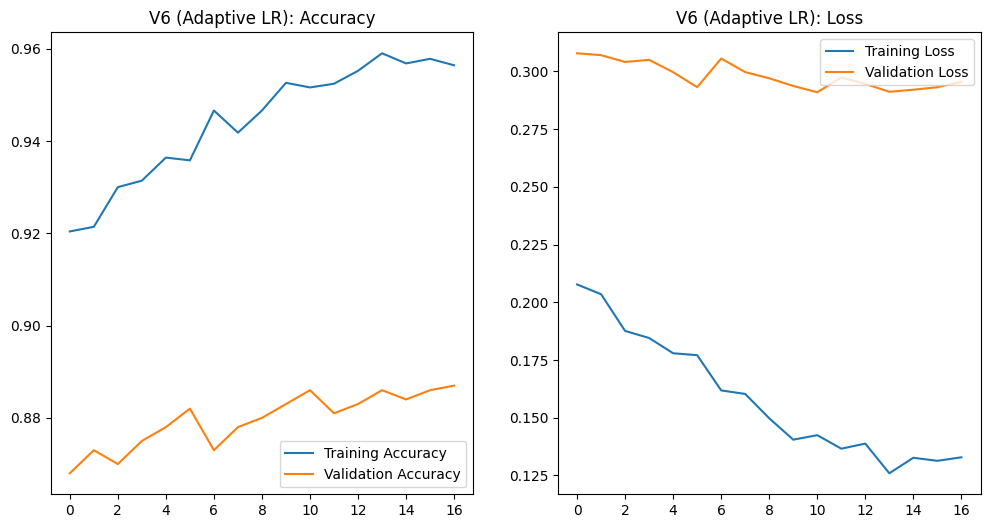

Đã lưu model định dạng mới: final_model_v6.keras


In [ ]:
# CELL 12: VERSION 6 - Adaptive Learning Rate (Scheduler)
# Tiếp tục train từ model_v5
from tensorflow.keras.callbacks import ReduceLROnPlateau

print("Đang cấu hình Version 6...")

# 1. ĐỊNH NGHĨA CALLBACK MỚI
# ReduceLROnPlateau: Giảm LR khi mô hình gặp bế tắc
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,       # Giảm LR xuống còn 20% so với trước đó (chia 5)
    patience=3,       # Chờ 3 epoch, nếu không cải thiện thì mới giảm
    min_lr=1e-7,      # Không giảm quá mức này
    verbose=1         # In thông báo ra màn hình khi giảm LR
)

# Cập nhật lại danh sách callbacks
# Vẫn giữ EarlyStopping và Checkpoint, thêm reduce_lr vào
callbacks_v6 = [
    EarlyStopping(monitor='val_loss', patience=6, verbose=1, restore_best_weights=True), # Tăng patience lên chút
    # SỬA LỖI WARNING: Đổi đuôi file thành .keras
    ModelCheckpoint('model_v6_best.keras', monitor='val_loss', save_best_only=True),
    reduce_lr
]

# 2. HUẤN LUYỆN TIẾP
# Ta dùng lại model_v5 (đang chứa trọng số tốt nhất của V5)
model_v6 = model_v5

print("Bắt đầu huấn luyện Version 6 (Adaptive LR)...")
history_v6 = model_v6.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, # Chạy thêm 20 epoch nữa
    initial_epoch=0,
    callbacks=callbacks_v6
)

# 3. VẼ BIỂU ĐỒ
acc = history_v6.history['accuracy']
val_acc = history_v6.history['val_accuracy']
loss = history_v6.history['loss']
val_loss = history_v6.history['val_loss']
real_epochs = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(real_epochs, acc, label='Training Accuracy')
plt.plot(real_epochs, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('V6 (Adaptive LR): Accuracy')

plt.subplot(1, 2, 2)
plt.plot(real_epochs, loss, label='Training Loss')
plt.plot(real_epochs, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('V6 (Adaptive LR): Loss')
plt.show()

# Lưu model cuối cùng với định dạng mới
model_v6.save('final_model_v6.keras')
print("Đã lưu model định dạng mới: final_model_v6.keras")

Đang tải lại Model tốt nhất từ V6...
Đã áp dụng Label Smoothing. Bắt đầu train V7...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 62 variables whereas the saved optimizer has 122 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 109ms/step - accuracy: 0.9544 - loss: 0.3100 - val_accuracy: 0.8730 - val_loss: 0.4524 - learning_rate: 1.0000e-05
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.9554 - loss: 0.3075 - val_accuracy: 0.8770 - val_loss: 0.4439 - learning_rate: 1.0000e-05
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - accuracy: 0.9615 - loss: 0.3006 - val_accuracy: 0.8760 - val_loss: 0.4481 - learning_rate: 1.0000e-05
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.9609 - loss: 0.2968 - val_accuracy: 0.8710 - val_loss: 0.4432 - learning_rate: 1.0000e-05
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - accuracy: 0.9625 - loss: 0.2921 - val_accuracy: 0.8760 - val_loss: 0.4331 - learning_rate: 1.0000e-05
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.9625 - loss: 0.2885 - val_accuracy: 0.8820 - val_loss: 0.4275 - learning_rate: 1.0000e-05
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - ac

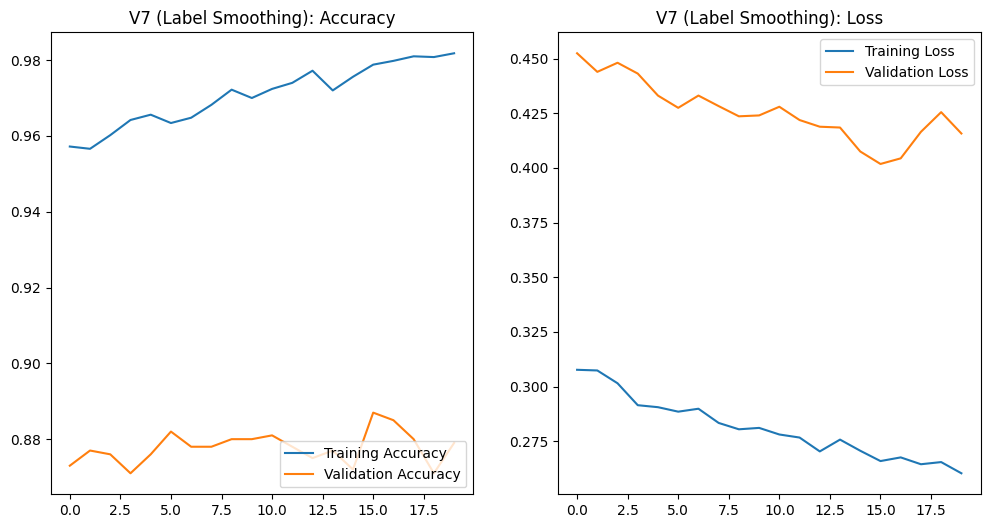

In [ ]:
# CELL 13: VERSION 7 - Label Smoothing
from tensorflow.keras.losses import BinaryCrossentropy

print("Đang tải lại Model tốt nhất từ V6...")
# Load lại model tốt nhất của V6 để đảm bảo xuất phát điểm cao nhất
model_v7 = tf.keras.models.load_model('model_v6_best.keras')

# -----------------------------------------------------------
# KỸ THUẬT: LABEL SMOOTHING
# -----------------------------------------------------------
# Thay vì dùng 'binary_crossentropy' string mặc định, ta khởi tạo class
# label_smoothing=0.1 nghĩa là: 0 -> 0.1 (hoặc 0.05 tùy backend), 1 -> 0.9
loss_fn = BinaryCrossentropy(label_smoothing=0.1)

# Compile lại mô hình
# Ta reset Learning Rate về 1e-5 để mô hình có thể điều chỉnh theo Loss mới
model_v7.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                 loss=loss_fn,
                 metrics=['accuracy'])

print("Đã áp dụng Label Smoothing. Bắt đầu train V7...")

# Callback: Vẫn giữ ReduceLROnPlateau nhưng reset lại thông số
callbacks_v7 = [
    EarlyStopping(monitor='val_loss', patience=6, verbose=1, restore_best_weights=True),
    ModelCheckpoint('model_v7_best.keras', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]

history_v7 = model_v7.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_v7
)

# -----------------------------------------------------------
# VẼ BIỂU ĐỒ
# -----------------------------------------------------------
acc = history_v7.history['accuracy']
val_acc = history_v7.history['val_accuracy']
loss = history_v7.history['loss']
val_loss = history_v7.history['val_loss']
real_epochs = range(len(acc))

plt.figure(figsize=(12, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(real_epochs, acc, label='Training Accuracy')
plt.plot(real_epochs, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('V7 (Label Smoothing): Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(real_epochs, loss, label='Training Loss')
plt.plot(real_epochs, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('V7 (Label Smoothing): Loss')
plt.show()

# Lưu model
model_v7.save('final_model_v7.keras')

Đang tải dữ liệu 256x256...
Found 5000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


/tmp/ipython-input-2029253154.py:28: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_new = tf.keras.applications.MobileNetV2(


--> Đang nạp trọng số từ: model_v7_best.keras
--> Nạp thành công! Tiếp tục train nâng cao.
Bắt đầu train Version 8 (RAM Safe Mode)...
Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 89s 342ms/step - accuracy: 0.8924 - loss: 0.3872 - val_accuracy: 0.8520 - val_loss: 0.4292 - learning_rate: 1.0000e-05
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 337ms/step - accuracy: 0.9180 - loss: 0.3429 - val_accuracy: 0.8570 - val_loss: 0.4251 - learning_rate: 1.0000e-05
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 334ms/step - accuracy: 0.9206 - loss: 0.3442 - val_accuracy: 0.8570 - val_loss: 0.4266 - learning_rate: 1.0000e-05
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 333ms/step - accuracy: 0.9420 - loss: 0.3154 - val_accuracy: 0.8550 - val_loss: 0.4259 - learning_rate: 1.0000e-05
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 336ms/step - accuracy: 0.9506 - loss: 0.3015 - val_accuracy: 0.8750 - val_loss: 0.3976 - learning_rate: 1.0000e-05
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 334ms/step - accuracy: 0.95

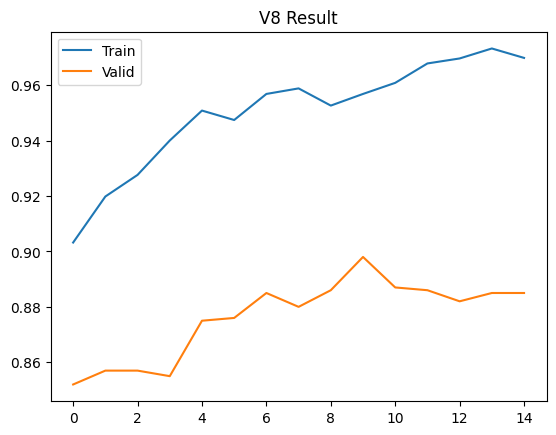

In [ ]:
# CELL 14 (FIXED): VERSION 8 - Progressive Resizing (RAM SAFE MODE)

# 1. LOAD DATASET 256x256 (KHÔNG DÙNG CACHE)
NEW_IMG_SIZE = (256, 256)
BATCH_SIZE = 32

print(f"Đang tải dữ liệu 256x256...")

train_ds_new = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=NEW_IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', shuffle=True
)
val_ds_new = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir, image_size=NEW_IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', shuffle=True
)

# CHỈ DÙNG PREFETCH (Tiết kiệm RAM), KHÔNG DÙNG CACHE
train_ds_new = train_ds_new.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds_new = val_ds_new.prefetch(buffer_size=tf.data.AUTOTUNE)

# 2. XÂY DỰNG KIẾN TRÚC MÔ HÌNH
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

base_model_new = tf.keras.applications.MobileNetV2(
    input_shape=(256, 256, 3),
    include_top=False,
    weights='imagenet'
)
base_model_new.trainable = True

inputs = tf.keras.Input(shape=(256, 256, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model_new(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_v8 = tf.keras.Model(inputs, outputs)

# 3. CHIẾN THUẬT NẠP TRỌNG SỐ THÔNG MINH
# Kiểm tra xem file model cũ có tồn tại không
weight_path = 'model_v7_best.keras'
# Nếu không có file .keras thì tìm file .h5 (phòng trường hợp cũ)
if not os.path.exists(weight_path):
    if os.path.exists('model_v6_best.keras'):
        weight_path = 'model_v6_best.keras'
        print("Không thấy V7, sẽ dùng tạm V6.")
    elif os.path.exists('baseline_model.h5'): # Hoặc bất kỳ model nào còn sót lại
         # Lưu ý: Load từ baseline vào architecture mới có thể lỗi shape,
         # nên an toàn nhất là nếu mất V7/V6 thì train từ đầu (ImageNet)
         weight_path = None

if weight_path and os.path.exists(weight_path):
    print(f"--> Đang nạp trọng số từ: {weight_path}")
    try:
        model_v8.load_weights(weight_path)
        print("--> Nạp thành công! Tiếp tục train nâng cao.")
    except:
        print("--> Lỗi nạp file (có thể do file lỗi khi crash). Sẽ train từ ImageNet.")
else:
    print("--> Không tìm thấy model cũ (đã mất do crash). Sẽ train V8 từ đầu (ImageNet weights).")
    print("--> Đừng lo, MobileNetV2 học rất nhanh!")

# 4. COMPILE & TRAIN
loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1)

model_v8.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                 loss=loss_fn,
                 metrics=['accuracy'])

callbacks_v8 = [
    EarlyStopping(monitor='val_loss', patience=6, verbose=1, restore_best_weights=True),
    ModelCheckpoint('model_v8_256px.keras', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]

print("Bắt đầu train Version 8 (RAM Safe Mode)...")
history_v8 = model_v8.fit(
    train_ds_new,
    validation_data=val_ds_new,
    epochs=15,
    callbacks=callbacks_v8
)

# Vẽ biểu đồ nhanh để kiểm tra
import matplotlib.pyplot as plt
plt.plot(history_v8.history['accuracy'], label='Train')
plt.plot(history_v8.history['val_accuracy'], label='Valid')
plt.legend()
plt.title('V8 Result')
plt.show()

--- Đang nạp dữ liệu 256x256 cho Version 9 ---
Found 5000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
--- Đang khởi tạo EfficientNetB0 ---
Sử dụng Optimizer: AdamW
--- Bắt đầu Train V9 ---
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 126s 480ms/step - accuracy: 0.5987 - loss: 0.8528 - val_accuracy: 0.7680 - val_loss: 0.5440 - learning_rate: 1.0000e-04
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 71s 450ms/step - accuracy: 0.7931 - loss: 0.5361 - val_accuracy: 0.8500 - val_loss: 0.4230 - learning_rate: 1.0000e-04
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 71s 451ms/step - accuracy: 0.8639 - loss: 0.4446 - val_accuracy: 0.8820 - val_loss: 0.3976 - learning_rate: 1.0000e-04
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 71s 453ms/step - accuracy: 0.8934 - loss: 0.4047 - val_accuracy: 0.8850 - val_loss: 0.3931 - learning_rate: 1.0000e-04
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 454ms/step - accuracy: 0.9094 - loss: 0.3681 - val_accuracy: 0.9080 - val_loss: 0.3731 - learning_rate:

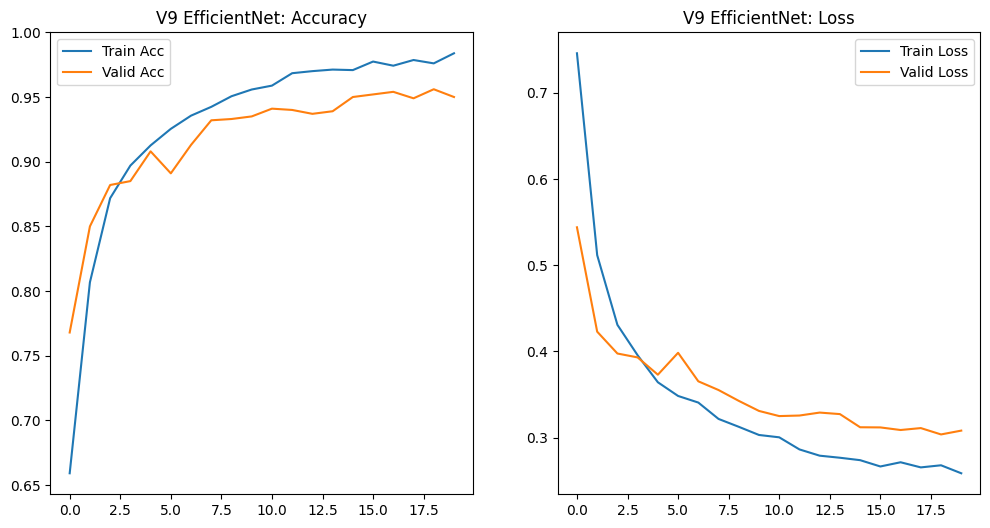

In [ ]:
# CELL 15: VERSION 9 - EfficientNetB0 (All-in-One)
# Chạy cell này độc lập, không cần chạy lại V8.

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os

# -----------------------------------------------------------
# BƯỚC 1: NẠP LẠI DỮ LIỆU (Vì là runtime mới)
# -----------------------------------------------------------
# Cấu hình đường dẫn (Đảm bảo đúng với môi trường của bạn)
base_dir = 'mini_dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')

# Cấu hình ảnh chuẩn 256x256 (Native Resolution)
IMG_SIZE = (256, 256)
BATCH_SIZE = 32

print("--- Đang nạp dữ liệu 256x256 cho Version 9 ---")
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', shuffle=True
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', shuffle=True
)

# Tối ưu hóa bộ nhớ (Prefetch only - An toàn cho RAM)
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# -----------------------------------------------------------
# BƯỚC 2: XÂY DỰNG MODEL EFFICIENTNET B0
# -----------------------------------------------------------
print("--- Đang khởi tạo EfficientNetB0 ---")

# Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# Base Model: EfficientNetB0
# Lưu ý: EfficientNet mạnh hơn MobileNet, học được đặc trưng phức tạp hơn
base_model = EfficientNetB0(
    input_shape=(256, 256, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = True # Fine-tune ngay từ đầu

inputs = tf.keras.Input(shape=(256, 256, 3))
x = data_augmentation(inputs)
# EfficientNet có lớp xử lý input riêng bên trong, nhưng gọi preprocess_input cho chắc chắn
# (Note: EfficientNet mong đợi input 0-255, preprocess_input sẽ tự lo việc scale)
x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False) # training=False để khóa BatchNormalization statistics
x = layers.GlobalAveragePooling2D()(x)

# Head (Phần phân loại)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x) # Tăng Dropout lên 0.4 vì EfficientNet dễ overfit hơn

outputs = layers.Dense(1, activation='sigmoid')(x)

model_v9 = tf.keras.Model(inputs, outputs)

# -----------------------------------------------------------
# BƯỚC 3: HUẤN LUYỆN
# -----------------------------------------------------------
# Sử dụng Label Smoothing để giúp model tổng quát hóa tốt hơn
loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1)

# Optimizer
try:
    # AdamW thường tốt hơn cho các kiến trúc mới (nếu TF hỗ trợ)
    optimizer = optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4)
    print("Sử dụng Optimizer: AdamW")
except:
    optimizer = optimizers.Adam(learning_rate=1e-4)
    print("Sử dụng Optimizer: Adam (Standard)")

model_v9.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True),
    ModelCheckpoint('model_v9_efficientnet.keras', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]

print("--- Bắt đầu Train V9 ---")
history_v9 = model_v9.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

# -----------------------------------------------------------
# BƯỚC 4: VẼ BIỂU ĐỒ
# -----------------------------------------------------------
import matplotlib.pyplot as plt

acc = history_v9.history['accuracy']
val_acc = history_v9.history['val_accuracy']
loss = history_v9.history['loss']
val_loss = history_v9.history['val_loss']
real_epochs = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(real_epochs, acc, label='Train Acc')
plt.plot(real_epochs, val_acc, label='Valid Acc')
plt.title('V9 EfficientNet: Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(real_epochs, loss, label='Train Loss')
plt.plot(real_epochs, val_loss, label='Valid Loss')
plt.title('V9 EfficientNet: Loss')
plt.legend()
plt.show()

--- Đang chuẩn bị dữ liệu để đánh giá chi tiết ---
Found 1000 files belonging to 2 classes.
Đang dự đoán trên tập Validation...
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 153ms/step

BẢNG ĐÁNH GIÁ HIỆU NĂNG (VERSION 9)
              precision    recall  f1-score   support

        Real       0.96      0.95      0.96       500
        Fake       0.95      0.96      0.96       500

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



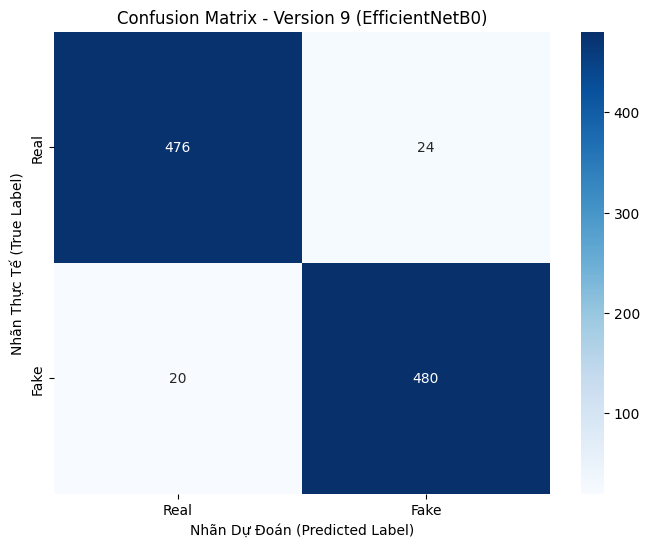

In [ ]:
# -----------------------------------------------------------
# BƯỚC 5: ĐÁNH GIÁ CHI TIẾT & MA TRẬN NHẦM LẪN
# -----------------------------------------------------------
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

print("--- Đang chuẩn bị dữ liệu để đánh giá chi tiết ---")

# 1. Load lại tập Validation với shuffle=False
# (Bắt buộc phải làm bước này để nhãn dự đoán khớp thứ tự với nhãn thật)
val_ds_eval = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False # QUAN TRỌNG: Không được trộn ảnh
)

# 2. Thực hiện dự đoán
print("Đang dự đoán trên tập Validation...")
y_pred_probs = model_v9.predict(val_ds_eval)
y_pred = (y_pred_probs > 0.5).astype(int) # Chuyển xác suất thành nhãn 0/1

# 3. Lấy nhãn thực tế (Ground Truth)
y_true = np.concatenate([y for x, y in val_ds_eval], axis=0)

# 4. In Bảng báo cáo (Classification Report)
print("\n" + "="*50)
print("BẢNG ĐÁNH GIÁ HIỆU NĂNG (VERSION 9)")
print("="*50)
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

# 5. Vẽ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix - Version 9 (EfficientNetB0)')
plt.ylabel('Nhãn Thực Tế (True Label)')
plt.xlabel('Nhãn Dự Đoán (Predicted Label)')
plt.show()

In [ ]:
# CELL DOWNLOAD: Tải model V9 về máy tính
from google.colab import files
import os

filename = 'model_v9_efficientnet.keras'

if os.path.exists(filename):
    print(f"Đang chuẩn bị tải xuống {filename}...")
    files.download(filename)
else:
    print(f"Không tìm thấy file {filename}. Hãy kiểm tra lại tên file.")

Không tìm thấy file model_v9_efficientnet.keras. Hãy kiểm tra lại tên file.
